In [1]:
import sys
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pprint import pprint
from helper_functions import data_reader
from shapely.geometry import Point, MultiPoint, Polygon, MultiPolygon
from shapely.ops import nearest_points

### Load all relevant data


In [2]:
df_CF = data_reader.getCFs() # CFs for all ecoregions
df_ecoregions = data_reader.getEcoregions()
df_miningPolygons = data_reader.getMiningPolygons()
df_miningFacilities = data_reader.getMiningFacilities()
df_miningMinerals = data_reader.getMiningMinerals()
df_miningCommodities = data_reader.getMiningCommodities()
df_miningSourceIDs = data_reader.getSourceIDs()
df_miningMaterialIDs = data_reader.getMaterialIDs()
df_miningReserves = data_reader.getReserves()
df_materialsList = data_reader.getMaterialsList()

In [3]:
# Lookup tables
name_lookup = df_materialsList.set_index('material_id')['material_name'].to_dict()
prices_lookup = df_materialsList.set_index('material_id')['price/kg'].to_dict()

### Merge Characterisation factors to the ecoregions

In [4]:
# Unify datatype of ecoregion ids to ensure correct join
df_ecoregions['ECO_ID'] = df_ecoregions['ECO_ID'].astype(int)
df_CF['eco_id'] = df_CF['eco_id'].astype(int)

# Drop unnecessary columns
df_ecoregions = df_ecoregions.drop(
    columns=['OBJECTID', 'AREA', 'PERIMETER', 'REALM', 'BIOME',
    'ECO_NUM', 'ECO_SYM', 'GBL_STAT', 'G200_REGIO', 'G200_NUM',
    'G200_BIOME', 'G200_STAT', 'Shape_Leng', 'Shape_Area', 'area_km2',
    'eco_code', 'PER_area', 'PER_area_1', 'PER_area_2'], axis=1
)
df_CF = df_CF.drop(
    columns=["realm","biome","eco_name","species_group","kingdom"], axis=1
)

# Group CFs by ecoregion into list of dicts
df_CF_grouped = (
    df_CF.groupby("eco_id")
    .apply(lambda g: g.to_dict(orient="records"), include_groups=False)  # list of row-dicts
    .reset_index(name="cf_data")  # put it into a column
)

# Merge CFs with ecoregions
df_CF_ecoregions = df_ecoregions.merge(
    df_CF_grouped, left_on='ECO_ID', right_on='eco_id'
).drop(columns=['eco_id'], axis=1 # drop duplicate eco_id column
).rename(columns={'ECO_NAME': 'eco_name', 'ECO_ID': 'eco_id', 'geometry':'eco_geometry'}) # rename for clarity

# Set geometry to ecoregion geometry
df_CF_ecoregions.set_geometry("eco_geometry", inplace=True)

# Check which ecoregions don't have a match in df_CF
matched_ids = df_CF['eco_id'].unique()
all_ids = df_ecoregions['ECO_ID'].unique()
missing_ids = np.setdiff1d(all_ids, matched_ids)
unmatched_names = df_ecoregions[df_ecoregions['ECO_ID'].isin(missing_ids)]['ECO_NAME'].unique()
print(f"CF has {len(matched_ids)} ecoregions and in total there would be {len(all_ids)}.\n"
    f"The unmatched ecoregions are {missing_ids}, {unmatched_names} which are now absent in the further analysis.")

# Check if crs is EPSG4326, change it otherwise
if df_CF_ecoregions.crs != "EPSG:4326":
    df_CF_ecoregions = df_CF_ecoregions.to_crs("EPSG:4326")
else:
    print("CRS is already EPSG:4326")

CF has 825 ecoregions and in total there would be 827.
The unmatched ecoregions are [-9999 -9998], ['Rock and Ice' 'Lake'] which are now absent in the further analysis.
CRS is already EPSG:4326


### Prepare Jasansky data

In [5]:
# Group reserves by facility and year
cols_to_keep = ["material", "mineral_value_tonnes", "commodity", "commodity_value_tonnes"]

df_groupedReserves = (
    df_miningReserves.groupby(["facility_id", "year"])
    .apply(lambda g: g[cols_to_keep].to_dict(orient="records"), include_groups=False)
    .reset_index(name="res_data")
)


def get_newest_data(group):
    """
    Select the newest data per commodity for each facility
    """
    group = group.sort_values("year", ascending=False).reset_index(drop=True)
    
    # Start with newest year as base
    newest_year = group.loc[0, 'year']
    combined = {
        item['commodity']: {**item, 'year': newest_year}
        for item in group.loc[0, 'res_data']
    }
    
    # Add commodities from older years if missing
    for _, row in group.iloc[1:].iterrows():
        year = row["year"]
        for item in row["res_data"]:
            commodity = item.get("commodity")
            if commodity not in combined:
                combined[commodity] = {**item, "year": year}
    
    return pd.Series({'res_data': list(combined.values())})

# Apply the function per facility
df_facility_reserves = (
    df_groupedReserves.groupby('facility_id')
    .apply(get_newest_data, include_groups=False)
    .reset_index()
)

In [6]:
df_wholeFacilities = df_miningFacilities[df_miningFacilities['facility_id'].str.endswith("00") & ~df_miningFacilities.geometry.is_empty].copy()

# Keep only these that have not stopped production
df_wholeFacilities = df_wholeFacilities[(df_wholeFacilities['production_end'].isnull())].copy()

# Drop unnecessary columns
df_wholeFacilities = df_wholeFacilities.drop(columns=[
    'facility_name', 'facility_other_names', 'sub_site_name', 'sub_site_other_names', 'production_start', 'GID_0', 'GID_1', 'GID_2', 'GID_3', 'GID_4', 'production_start', 'production_end'
])

# Merge reserves with whole facilities, only keep those with geometry
df_facility_reserves = df_wholeFacilities.merge(df_facility_reserves, on='facility_id', how='inner')

print(len(df_facility_reserves), "whole facilities with reserve data and geometry")
print(df_facility_reserves['surface_area_sq_km'].nunique(), "facilities have a surface area value")
print(df_facility_reserves['concession_area_sq_km'].nunique(), "facilities have a concession area value")

612 whole facilities with reserve data and geometry
11 facilities have a surface area value
68 facilities have a concession area value


In [7]:
def joinSinglePoint(single_points, polygons, max_distance=1000):
# Copy to avoid modifying original
    points = single_points.copy()
    polys = polygons.copy()
    
    # Track which polygons have been assigned
    used_polygons = set()
    used_geometries = list()
    # List to collect results
    results = []

    # Compute all distances between points and polygons (optional: limit to max_distance)
    # Using GeoPandas spatial indexing can speed this for large datasets
    for _, point in points.iterrows():
        # Candidates: polygons within max_distance
        polys_within = polys[polys.distance(point.geometry) <= max_distance].copy()
        if polys_within.empty:
            #print(f"No polygons within {max_distance}m for facility {point['facility_id']}")
            combined = {**point.to_dict(), 'ISO3_CODE': None, 'COUNTRY_NAME': None, 'AREA': None, 'polygon_geometry': None, 'distance': None}
            results.append(combined)
            continue

        # Sort candidates by distance
        polys_within['distance'] = polys_within.geometry.distance(point.geometry)
        polys_within = polys_within.sort_values('distance')
        
        # Pick the closest polygon not already assigned
        for poly_idx, poly_row in polys_within.iterrows():
            if poly_idx not in used_polygons:
                # Assign
                used_polygons.add(poly_idx)
                used_geometries.append(poly_row['geometry'])
                poly_row = poly_row.rename({'geometry':'polygon_geometry'})
                
                # Combine point + polygon info
                combined = {**point.to_dict(), **poly_row.to_dict()}
                results.append(combined)

                break  # Move to next point
    
    # Convert results to DataFrame
    if results:
        df_result = pd.DataFrame(results)
    else:
        #print(f"No results")
        return 
    
    matched_ids = set(df_result['facility_id'])
    unmatched1 = points[~points['facility_id'].isin(matched_ids)]
    #print(len(unmatched1), "unmatched points")

    # Unmatched points that have a surface area value
    unmatched2 = unmatched1[unmatched1["surface_area_sq_km"].notnull()]
    #print(len(unmatched2), "unmatched points with surface area")

    # Points that are still unmatched (no polygon and no surface area)
    still_unmatched = unmatched1[~unmatched1['facility_id'].isin(unmatched2['facility_id'])]
    #print(len(still_unmatched), "still unmatched points")

    # Save for manual review
    #still_unmatched.to_file("data/manual/unmatched_single_points.geojson", driver="GeoJSON")

    # Add the unmatched-with-surface-area points back into the results
    df_result = pd.concat([df_result, unmatched2], ignore_index=True)

    df_result = gpd.GeoDataFrame(df_result, geometry='geometry', crs=points.crs)

    # Back to WGS84
    df_result = df_result.to_crs("EPSG:4326")
    
    return df_result, used_geometries 

#TODO: If wanted, minimize for total distance between points and polygons

In [8]:
def joinMultiPoints(multi_points, polygons, all_facilities, max_distance=1000):
    """
    Join multipoint facilities (with submines) to polygons.
    If multiple submines exist: match all submines individually, sum their polygon areas,
    and keep only the geometry of the first submine as representative.
    If only one submine: treat like a single-point facility.
    """

    multis = multi_points.copy()
    polys = polygons.copy()
    all_facs = all_facilities.copy()

    results = []
    all_used_geoms = []

    for _, facility_row in multis.iterrows():
        prefix = facility_row["facility_id"][:9]
        subs = all_facs[
            (all_facs["facility_id"].str.startswith(prefix)) &
            (~all_facs["facility_id"].str.endswith("00"))
        ].copy()

        # No submines
        if subs.empty:
            #print(f"No sub-mines for multipoint facility {facility_row['facility_id']}")
            continue

        # One submine
        elif len(subs) == 1:
            sub = subs.iloc[[0]]
            joined_sub, used_geoms = joinSinglePoint(sub, polys, max_distance=max_distance)
            polys = polys[~polys.geometry.isin(used_geoms)].copy()

            if len(joined_sub) > 0:
                results.append(joined_sub.iloc[0].to_dict())
                all_used_geoms.extend(used_geoms)

        # Multiple submines
        else:
            joined_subs, used_geoms = joinSinglePoint(subs, polys, max_distance=max_distance)
            polys = polys[~polys.geometry.isin(used_geoms)].copy()
            all_used_geoms.extend(used_geoms)
            
            if len(joined_subs) == 0:
                #print(f"No unused polygons found for submines of {facility_row['facility_id']}")
                continue


            # Convert AREA to numeric
            joined_subs["AREA"] = pd.to_numeric(joined_subs["AREA"], errors='coerce')

            # Pick representative submine
            valid_subs = joined_subs[joined_subs['AREA'].notna() | joined_subs['surface_area_sq_km'].notna()]
            if not valid_subs.empty:
                rep_submine = valid_subs.iloc[0].copy()
            else:
                rep_submine = joined_subs.iloc[-1].copy()

            # Sum polygon areas of all matched submines (use all matched polygons, not just valid_subs)
            total_polygon_area = joined_subs["AREA"].sum(skipna=True)

            # Combine parent facility info with polygon attributes
            combined = {
                **facility_row.to_dict(),  # facility-level info
                **rep_submine[['ISO3_CODE', 'COUNTRY_NAME', 'polygon_geometry', 'distance']].to_dict()  # keep polygon info
            }

            # Overwrite key fields
            combined["AREA"] = total_polygon_area       # summed polygon area
            combined["geometry"] = rep_submine["geometry"]  # first submine's point

            # Append to results
            results.append(combined)
            
    # Convert results to GeoDataFrame
    if results:
        df_result = gpd.GeoDataFrame(results, geometry="geometry", crs=multi_points.crs)
    else:
        #print("No multipoint facilities matched any polygons.")
        df_result = gpd.GeoDataFrame(columns=list(multi_points.columns) + ['ISO3_CODE', 'COUNTRY_NAME', 'AREA', 'polygon_geometry', 'distance'], crs=multi_points.crs)

    # Change crs back to WGS84
    df_result = df_result.to_crs("EPSG:4326")

    return df_result


In [9]:
assert df_miningPolygons.crs == df_facility_reserves.crs, f"{df_miningPolygons.crs} vs {df_facility_reserves.crs}"

# Convert to projected CRS for distance calculations (Web Mercator (meters))
df_facility_reserves = df_facility_reserves.to_crs(3857)
df_miningPolygons = df_miningPolygons.to_crs(3857)
df_miningFacilities = df_miningFacilities.to_crs(3857)

# Split facilities in single points and multiple points when all geometries are multipoints
df_singlePoints = df_facility_reserves[
    df_facility_reserves.geometry.apply(
        lambda g: isinstance(g, MultiPoint) and len(g.geoms) == 1
    )
].copy()
df_singlePoints['geometry'] = df_singlePoints['geometry'].apply(lambda g: list(g.geoms)[0])  # extract the single Point
print(len(df_singlePoints), "single point facilities")

df_multiPoints = df_facility_reserves[
    df_facility_reserves.geometry.apply(
        lambda g: isinstance(g, MultiPoint) and len(g.geoms) > 1
    )
].copy()
print(len(df_multiPoints), "multiple point facilities")

# Join single points with polygons
df_singlePoint_facilities_polygons, used_geometries = joinSinglePoint(df_singlePoints, df_miningPolygons)

# Keep only rows where at least one of AREA or surface_area_sq_km is not null
df_singlePoint_facilities_polygons = df_singlePoint_facilities_polygons[
    (df_singlePoint_facilities_polygons['AREA'].notna() & (df_singlePoint_facilities_polygons['AREA'] != 0)) |
    df_singlePoint_facilities_polygons['surface_area_sq_km'].notna()
].copy()

print(f"{len(df_singlePoint_facilities_polygons)} single point facilities matched with polygons")

# Remove used polygons from the pool for multipoint matching
print(len(used_geometries), "polygons used for single point facilities")
print(len(df_miningPolygons), "polygons before removing used ones")
df_remainingPolygons = df_miningPolygons[~df_miningPolygons.geometry.isin(used_geometries)].copy()
print(len(df_remainingPolygons), "polygons left for multipoint facilities")

# Join multipoints with remaining polygons
df_multiPoint_facilities_polygons = joinMultiPoints(df_multiPoints, df_remainingPolygons, df_miningFacilities)

# Keep only rows where at least one of AREA or surface_area_sq_km is not null
df_multiPoint_facilities_polygons = df_multiPoint_facilities_polygons[
    (df_multiPoint_facilities_polygons['AREA'].notna() & (df_multiPoint_facilities_polygons['AREA'] != 0)) |
    df_multiPoint_facilities_polygons['surface_area_sq_km'].notna()
].copy()

# Add single and multi point results to one dataframe
df_all_facilities_polygons = pd.concat(
    [df_singlePoint_facilities_polygons, df_multiPoint_facilities_polygons],
    ignore_index=True
)
print(len(df_all_facilities_polygons), "usable mines")

df_miningFacilities = df_miningFacilities.to_crs("EPSG:4326")

print(df_all_facilities_polygons['geometry'])

529 single point facilities
83 multiple point facilities
464 single point facilities matched with polygons
464 polygons used for single point facilities
44929 polygons before removing used ones
44465 polygons left for multipoint facilities
543 usable mines
0      POINT (-101.87946 54.77482)
1        POINT (76.20841 14.22353)
2       POINT (-107.0829 45.80531)
3        POINT (20.96362 67.07507)
4        POINT (79.93182 46.95243)
                  ...             
538       POINT (0.00136 -0.00029)
539       POINT (0.00127 -0.00012)
540        POINT (0.00105 0.00032)
541          POINT (0.001 0.00036)
542        POINT (0.00061 0.00035)
Name: geometry, Length: 543, dtype: geometry


### Join the facilities and the characterisation factors

In [10]:
# Join the mines to the cf_data via the ecoregions
df_facilities_ecoregions = gpd.sjoin(df_all_facilities_polygons, df_CF_ecoregions, how="left", predicate='within', lsuffix="mining", rsuffix="CF_eco")

# Keep only the ones that are mines
df_mines_ecoregions = df_facilities_ecoregions[df_facilities_ecoregions['facility_type'].str.contains("Mine")].copy()

print(len(df_facilities_ecoregions), "facilities with polygons and ecoregions after spatial join")
print(len(df_mines_ecoregions), "of them are at least partly mines")

543 facilities with polygons and ecoregions after spatial join
537 of them are at least partly mines


### Create a new DataFrame with one row per commodity from df_mines_ecoregions

In [16]:
records = []
for _, row in df_mines_ecoregions.iterrows():
    res_data = row['res_data']
    cf_data = row['cf_data']

    total_commodity_kg = sum(entry.get('commodity_value_tonnes') * 1e3 for entry in res_data)
    total_material_kg = sum(entry.get('mineral_value_tonnes') * 1e3 for entry in res_data)

    facility_id = row['facility_id']
    location = row['geometry']
    #TODO: Check the different area columns on the units
    if row['AREA'] is not None and not (math.isnan(row['AREA'])):
        area = row['AREA']
    elif row['surface_area_sq_km'] is not None and not (math.isnan(row['surface_area_sq_km'])):
        area = row['surface_area_sq_km']
    else:
        print(f"Facility {facility_id} has no area information.")
        area = None
    ecoregion = row['eco_id']
    country = row['country']

    for entry in res_data:
        material = name_lookup.get(entry.get('material'))
        material_price = prices_lookup.get(entry.get('material'), 0)
        mineral_amount = entry.get('mineral_value_tonnes') * 1e3
        commodity = name_lookup.get(entry.get('commodity'))
        commodity_price = prices_lookup.get(entry.get('commodity'), 0)
        commodity_amount = entry.get('commodity_value_tonnes') * 1e3  # convert from tonnes to kg
        records.append({
            'Facility_ID': facility_id,
            'Location [POINT]': location,
            'Area [SQ_KM?]': area,
            'Ecoregion_ID': ecoregion,
            'Country': country,
            'Mineral_Name': material,
            'Mineral [kg]': mineral_amount,
            'Mineral_Price [€/kg]': material_price,
            'Commodity_Name': commodity,
            'Commodity [kg]': commodity_amount,
            'Commodity_Price [€/kg]': commodity_price,
        })

df_commodities_flat = gpd.GeoDataFrame(records)
df_commodities_flat.set_geometry('Location [POINT]', inplace=True)

# Calculate the factors
df_commodities_flat["Total mineral price [€]"] = df_commodities_flat["Mineral [kg]"] * df_commodities_flat["Mineral_Price [€/kg]"]
df_commodities_flat["Total facility mineral price [€]"] = df_commodities_flat.groupby("Facility_ID")["Total mineral price [€]"].transform('sum')
df_commodities_flat["Mineral Factor [m2/kg]"] = df_commodities_flat["Area [SQ_KM?]"] * 1e6 * df_commodities_flat["Total mineral price [€]"] / df_commodities_flat["Total facility mineral price [€]"] / df_commodities_flat["Mineral [kg]"]
df_commodities_flat["Total commodity price [€]"] = df_commodities_flat["Commodity [kg]"] * df_commodities_flat["Commodity_Price [€/kg]"]
df_commodities_flat["Total facility commodity price [€]"] = df_commodities_flat.groupby("Facility_ID")["Total commodity price [€]"].transform('sum')
df_commodities_flat["Commodity Factor [m2/kg]"] = df_commodities_flat["Area [SQ_KM?]"] * 1e6 * df_commodities_flat["Total commodity price [€]"] / df_commodities_flat["Total facility commodity price [€]"] / df_commodities_flat["Commodity [kg]"]

In [17]:
print(f"{df_commodities_flat[df_commodities_flat['Commodity Factor [m2/kg]'].notnull()]['Facility_ID'].nunique()} Facilities with factors for commodities")
print(f"{df_commodities_flat[df_commodities_flat['Mineral Factor [m2/kg]'].notnull()]['Facility_ID'].nunique()} Facilities with factors for minerals")
print(f"{df_commodities_flat[df_commodities_flat['Commodity Factor [m2/kg]'].notnull() | df_commodities_flat['Mineral Factor [m2/kg]'].notnull()]['Facility_ID'].nunique()} Facilities with factors for commodities and minerals")
minesWithCommodityFactors = df_commodities_flat[df_commodities_flat['Commodity Factor [m2/kg]'].notnull()].reset_index(drop=True)
minesWithCommodityFactors

# minesWithCommodityFactors.to_csv("data/manual/reserves_facilities.csv", index=False)

203 Facilities with factors for commodities
399 Facilities with factors for minerals
458 Facilities with factors for commodities and minerals


,Facility_ID,Location [POINT],Area [SQ_KM?],Ecoregion_ID,Country,Mineral_Name,Mineral [kg],Mineral_Price [€/kg],Commodity_Name,Commodity [kg],Commodity_Price [€/kg],Total mineral price [€],Total facility mineral price [€],Mineral Factor [m2/kg],Total commodity price [€],Total facility commodity price [€],Commodity Factor [m2/kg]
0,COM00016.00,POINT (-1.02314 6.34564),11.203951,30111.0,Ghana,Gold dominant ore,6.080000e+10,21400.00000,Gold,7.314177e+04,35300.00,1.301120e+15,1.301120e+15,0.000184,2.581904e+09,2.581904e+09,153.181295
1,COM00033.00,POINT (27.3499 -24.78439),0.293471,30717.0,South Africa,Platinum-group metal ore,1.035000e+11,1360.00000,PGM,4.280778e+05,54375.60,1.407600e+14,1.407600e+14,0.000003,2.327699e+10,2.327699e+10,0.685556
2,COM00035.00,POINT (48.31224 -18.82656),7.582316,30117.0,Madagascar,Laterite,1.245000e+11,0.00755,Cobalt,9.960000e+07,32.10,9.399750e+08,1.879950e+09,0.000030,3.197160e+09,1.689716e+10,0.014404
3,COM00035.00,POINT (48.31224 -18.82656),7.582316,30117.0,Madagascar,Laterite,1.245000e+11,0.00755,Nickel,1.096000e+09,12.50,9.399750e+08,1.879950e+09,0.000030,1.370000e+10,1.689716e+10,0.005609
4,COM00041.00,POINT (-70.2549 -33.09202),1.997347,61008.0,Chile,Copper dominant ore,1.163000e+12,0.84000,Copper,8.000000e+09,5.52,9.769200e+11,9.769200e+11,0.000002,4.416000e+10,4.416000e+10,0.000250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,COM01053.00,POINT (-0.0006 -0.0002),5.016225,NaN,Argentina,Gold dominant ore,1.037700e+10,21400.00000,Lead,1.179340e+08,1.64,2.220678e+14,6.662034e+14,0.000161,1.934118e+08,9.248746e+08,0.008895
307,COM01053.00,POINT (-0.0006 -0.0002),5.016225,NaN,Argentina,Gold dominant ore,1.037700e+10,21400.00000,Zinc,4.898798e+07,2.13,2.220678e+14,6.662034e+14,0.000161,1.043444e+08,9.248746e+08,0.011552
308,COM01105.00,POINT (0.00025 -0.00023),10.675597,NaN,South Africa,Platinum-group metal ore,6.920000e+11,1360.00000,PGM,2.146626e+06,54375.60,9.411200e+14,9.411200e+14,0.000015,1.167241e+11,1.167241e+11,4.973199
309,COM01308.00,POINT (-0.00105 0.00037),54.796739,NaN,United States of America,Gold dominant ore,8.140000e+10,21400.00000,Gold,3.212001e+05,35300.00,1.741960e+15,1.741960e+15,0.000673,1.133836e+10,1.133836e+10,170.600010


### Show mines

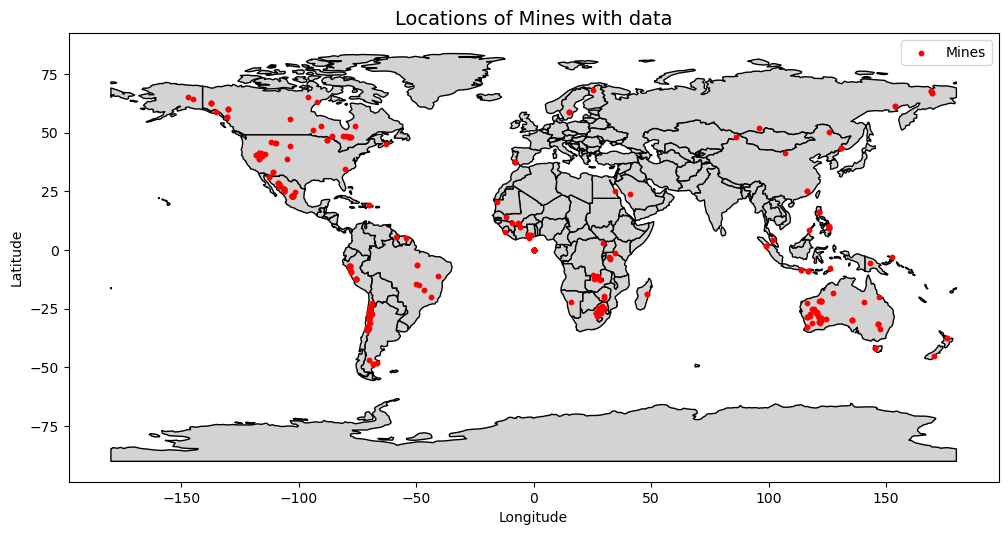

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the world basemap
world_path = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_path)
world.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the mines
minesWithCommodityFactors.plot(ax=ax, color='red', markersize=10, label="Mines")

# Add plot title and legend
plt.title("Locations of Mines with data", fontsize=14)
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Test

### Ore grade estimation (Not needed at the moment, but maybe down the line)

In [ ]:
#TODO: Get a proxy for grade_ppm if missing, e.g. average grade_ppm for that commodity in that country or globally 
# and then compute the commodity_value_tonnes from that

# Filter out rows that have no data
df_reserves = df_miningReserves[
    ~(df_miningReserves['mineral_value_tonnes'].isna() & 
      df_miningReserves['commodity_value_tonnes'].isna() | df_miningReserves['commodity'].isna())
].copy()

# Split into already available commodity data and missing ones
df_available_ppm = df_reserves[df_reserves['commodity_value_tonnes'].notna() & df_reserves['grade_ppm'].notna()]
df_missing = df_reserves[df_reserves['commodity_value_tonnes'].isna()]
print(df_available_ppm['commodity'].nunique(), "commodities with available commodity_value_tonnes and grade_ppm")
print(df_reserves['commodity'].nunique(), "commodities in total")
print(len(df_missing), "rows with missing commodity_value_tonnes")

# Compute stats per commodity
df_ppm = df_available_ppm.groupby('commodity')['grade_ppm'].agg(['mean', 'min', 'max', 'count']).reset_index()
df_ppm['commodity_name'] = df_ppm['commodity'].map(name_lookup)

# Count the number of rows per commodity
df_noppm = df_missing.groupby('commodity').size().reset_index(name='no_ppm_count')
df_noppm['commodity_name'] = df_noppm['commodity'].map(name_lookup)
# put them side by side
df_ppm = df_ppm.merge(df_noppm, on=['commodity', 'commodity_name'], how='outer')

# Compute mean grade per commodity
mean_ppm = df_available_ppm.groupby('commodity')['grade_ppm'].mean()

# Fill missing grade_ppm in df_missing directly
df_missing.loc[:, 'grade_ppm'] = df_missing['grade_ppm'].fillna(df_missing['commodity'].map(mean_ppm))
print(len(df_missing[df_missing['grade_ppm'].notna()]), 'rows now have grade_ppm estimated')
print(len(df_missing[df_missing['grade_ppm'].isna()]), 'rows still have grade_ppm missing and will be dropped')

df_ppm

# Compute number of non-null entries and percentage per column
summary = pd.DataFrame({
    'non_null_count': df_reserves.notnull().sum(),
    'percent': (df_reserves.notnull().mean() * 100)
})

# Reset index to have column names as a column
summary = summary.reset_index().rename(columns={'index': 'column_name'})

# Optionally, sort by percentage descending
summary = summary.sort_values(by='percent', ascending=False)

# Display the table
print(summary)

df_ppm[['commodity', 'commodity_name', 'mean', 'min', 'max', 'count', 'no_ppm_count']]